In [1]:
#Load dataset

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



file_path = "/Users/sajebqureshi/Desktop/DS/Pharma project/bank+marketing/bank-additional/bank-additional-full.csv"

df = pd.read_csv(file_path, sep=";")



In [2]:
#View data

print(df.head(5))
print(df.info())


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

# Mixed dataset with numerical and categorical dataset requires encoding and scaling

In [3]:
# Basic overview
print(df.shape)
print(df.columns)

# Summary stats
print(df.describe())

# Missing values
print(df.isnull().sum())

# Target distribution
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True))

# Data types
print(df.dtypes)

(41188, 21)
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')
               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.0

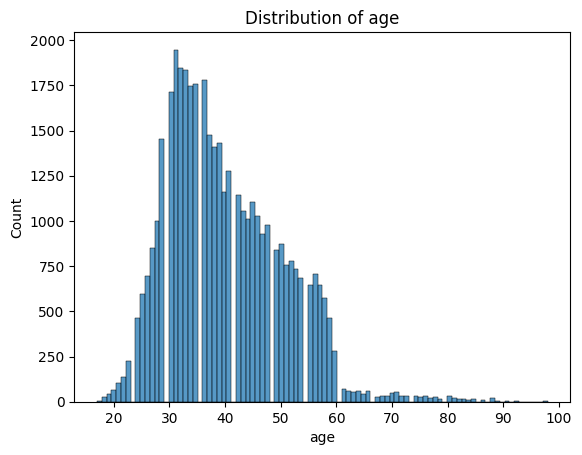

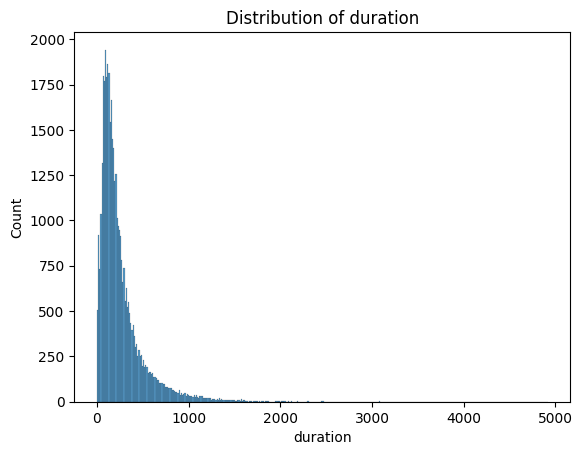

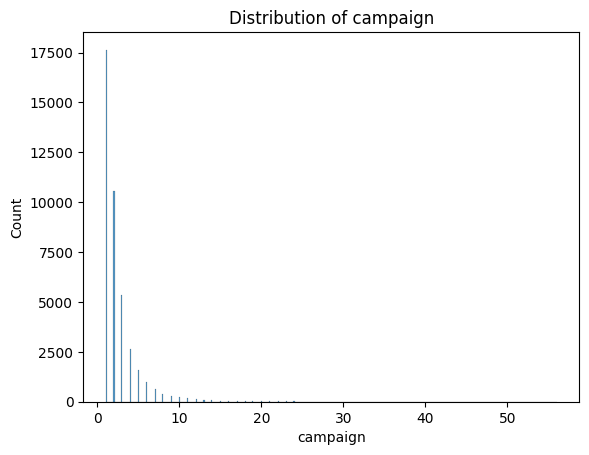

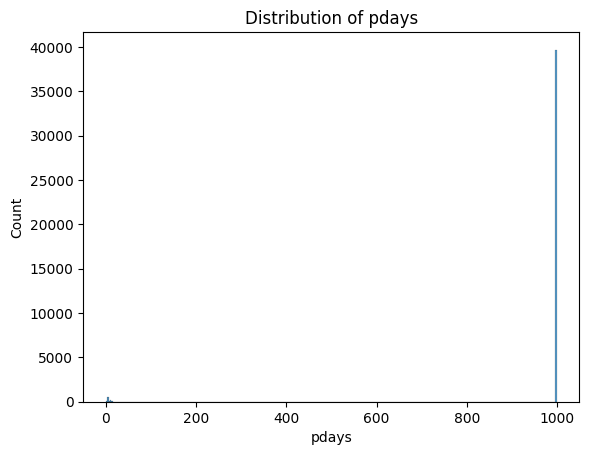

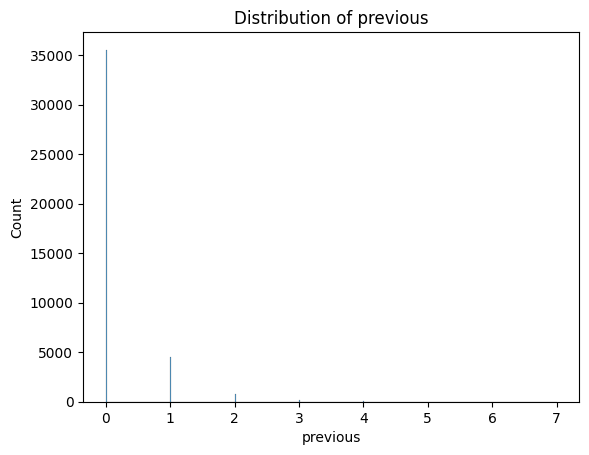

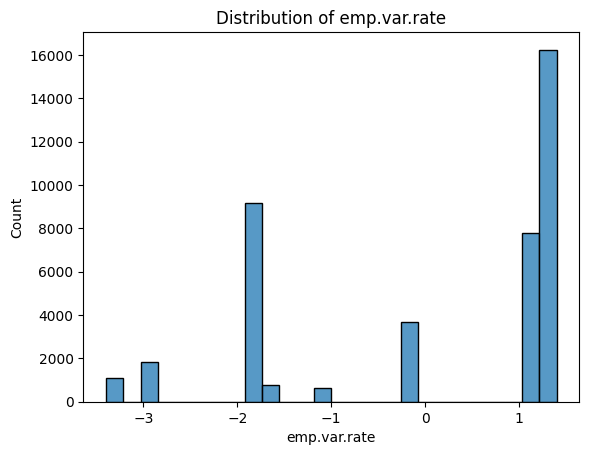

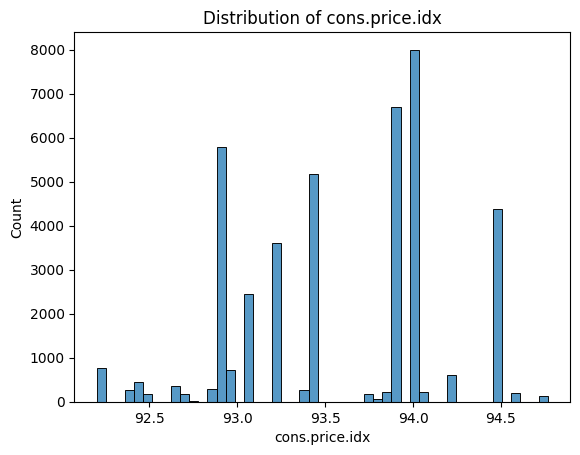

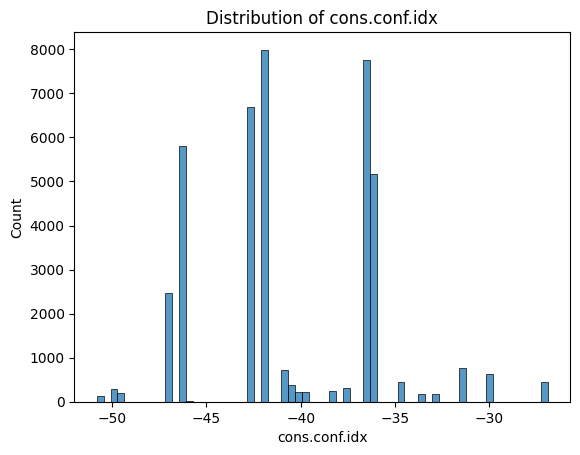

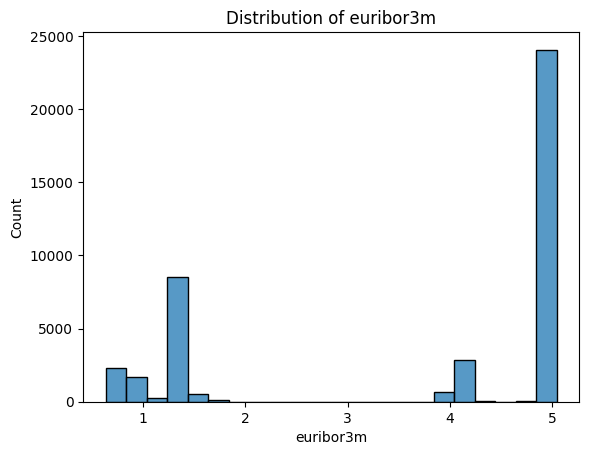

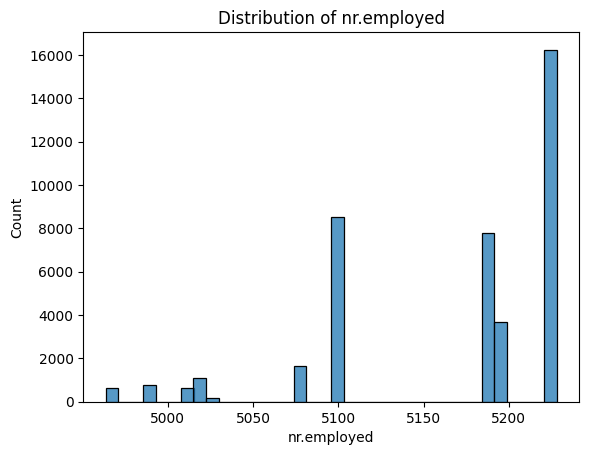

In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

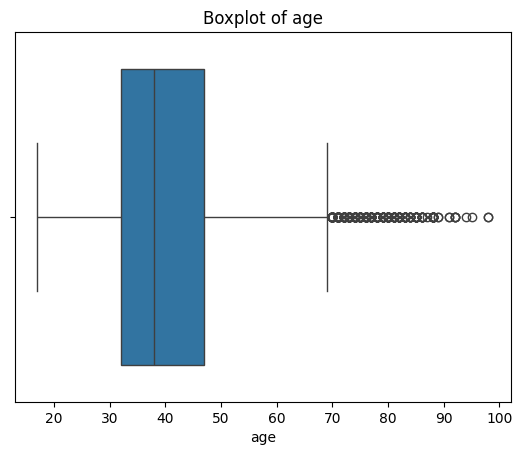

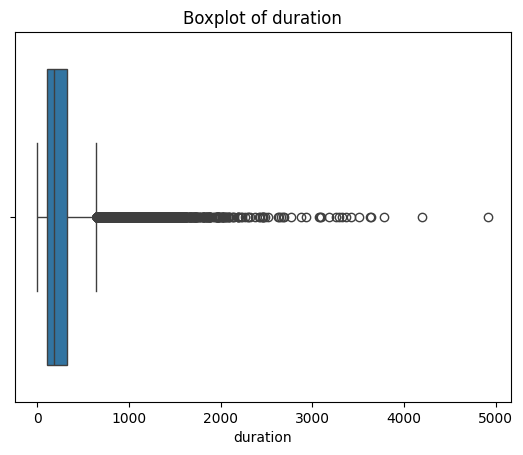

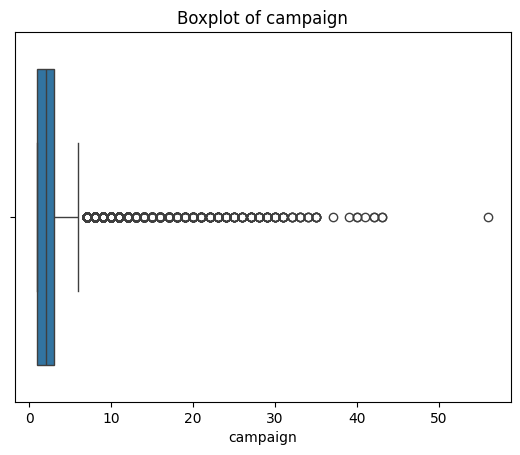

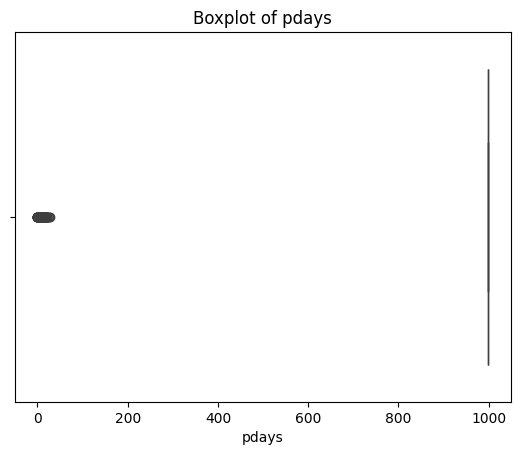

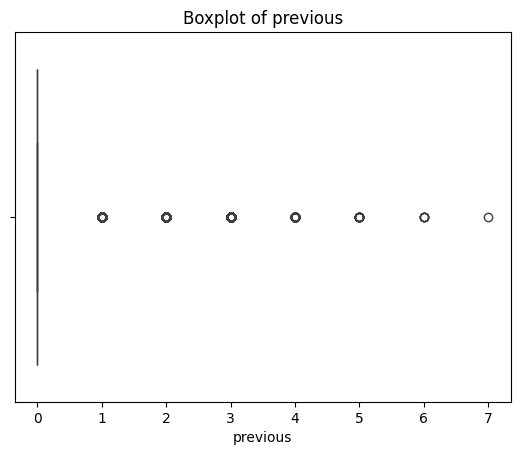

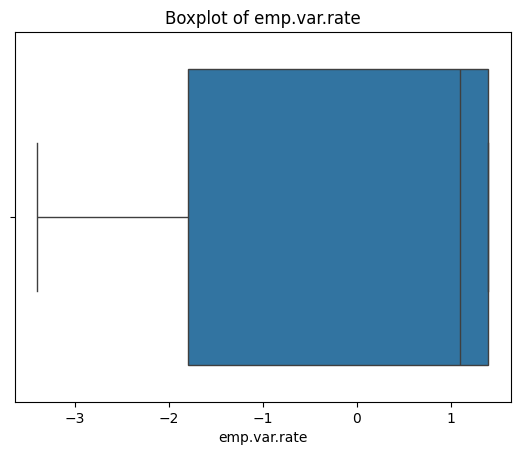

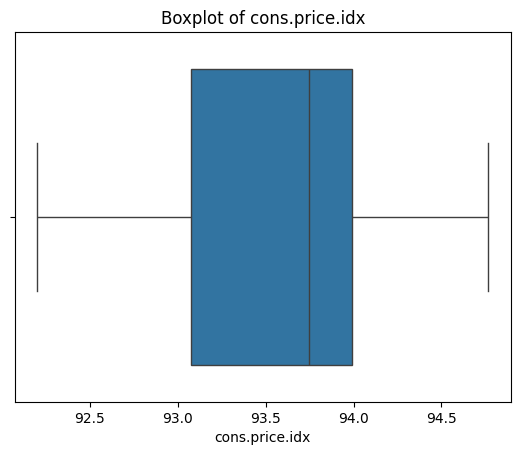

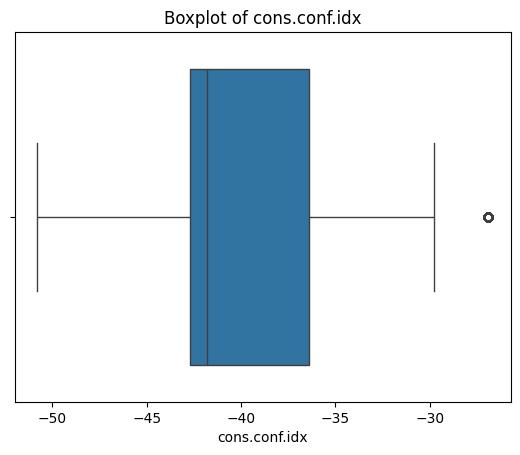

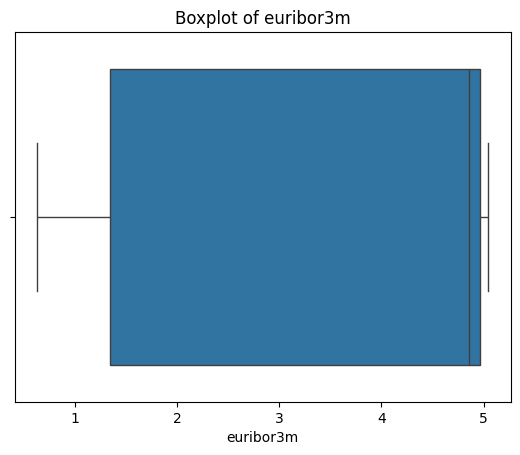

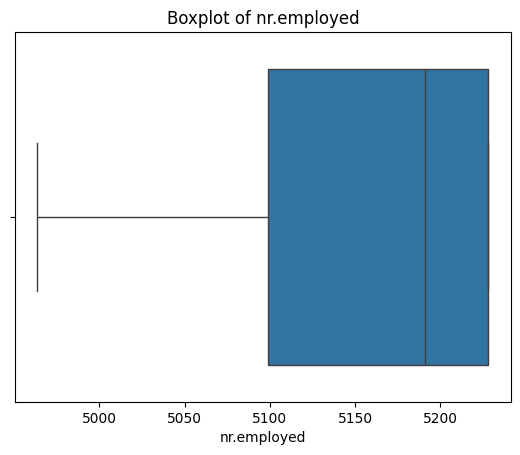

In [5]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [6]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

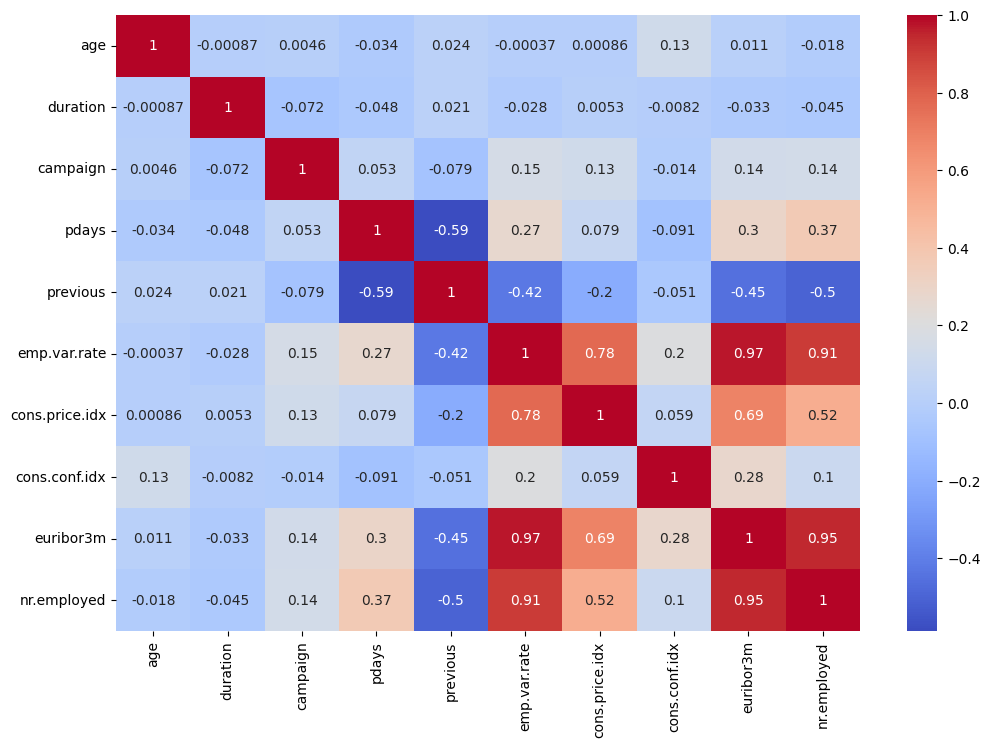

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [8]:
df.replace('unknown', np.nan, inplace=True)

In [9]:
#You are correcting meaning, not learning pattern

df['previous_contact'] = (df['pdays'] != 999).astype(int)
df=df.drop('pdays', axis=1)

In [10]:
#Remove multicollinearity before split
df = df.drop(['euribor3m', 'nr.employed'], axis=1)

In [11]:
df = df.drop('default', axis=1)

In [12]:
# Define features and target
X = df.drop('y', axis=1)
y = df['y']

# Identify feature types
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

In [13]:
# Convert target first 

y = y.map({'no': 0, 'yes': 1})

In [14]:
print(y.unique())

[0 1]


In [15]:
#Converted before cleaning the Y so,
#Reloading original data
df = pd.read_csv(file_path, sep=";")
df.columns = df.columns.str.strip()

#extract target again
y = df['y']

In [16]:
print(y.unique())

['no' 'yes']


In [17]:
print(y.isnull().sum())

0


In [18]:
y = y.map({'no':0, 'yes': 1})

In [19]:
print(y.unique())
print(y.isnull().sum())

[0 1]
0


In [20]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [21]:
!pip install xgboost

In [22]:
#Imports

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, r2_score, mean_squared_error

In [23]:


# Train-test split (stratify for classification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
#Identify categorical and numerical columns
num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

In [25]:
#Preprocessing pipeline(Fits on TRAIN only | Can transform test with same objects | Handles skew, missing, scaling, encoding)
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # missing values
    ('power', PowerTransformer()),                # correct skew
    ('scaler', StandardScaler())                  # scale
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

In [26]:
#Combine with smot and model in pipeline(SMOTE applied inside pipeline after preprocessing | No leakage occurs | Can easily swap models)

# Example: Logistic Regression pipeline
pipeline_lr = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),   # handle class imbalance
    ('model', LogisticRegression(max_iter=1000))
])

# Random Forest
pipeline_rf = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# XGBoost
pipeline_xgb = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

In [27]:
#Fit models

# Fit Logistic Regression
pipeline_lr.fit(X_train, y_train)

# Fit Random Forest
pipeline_rf.fit(X_train, y_train)

# Fit XGBoost
pipeline_xgb.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:08:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [28]:
#Predict and evaluate

models = {'Logistic Regression': pipeline_lr,
          'Random Forest': pipeline_rf,
          'XGBoost': pipeline_xgb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")

--- Logistic Regression ---
Accuracy: 0.8648943918426802
F1 Score: 0.6017889087656529
Confusion Matrix:
 [[6284 1026]
 [  87  841]]


--- Random Forest ---
Accuracy: 0.910536537994659
F1 Score: 0.6102591221575886
Confusion Matrix:
 [[6924  386]
 [ 351  577]]


--- XGBoost ---
Accuracy: 0.9132070890992959
F1 Score: 0.6073585941790225
Confusion Matrix:
 [[6970  340]
 [ 375  553]]




In [29]:
#Feature selection (optional)
# Example: RandomForest for feature importance
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))

pipeline_fs = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', selector),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_fs.fit(X_train, y_train)

# Test
y_pred_fs = pipeline_fs.predict(X_test)
print("After Feature Selection - Accuracy:", accuracy_score(y_test, y_pred_fs))
print("F1 Score:", f1_score(y_test, y_pred_fs))

After Feature Selection - Accuracy: 0.8931779558145181
F1 Score: 0.6160558464223386


## Eventhough feature selection reduced the accuracy because it reduced noise and helps in faster prediction

In [32]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Example with your Random Forest pipeline
pipeline_rf = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

# 1️⃣ Cross-validation (F1)
cv_scores = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='f1')
print("Cross-Validation F1 Score:", cv_scores.mean())

# 2️⃣ Hyperparameter Tuning with GridSearch
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10]
}

grid = GridSearchCV(pipeline_rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Hyperparameters:", grid.best_params_)

# 3️⃣ Final Evaluation on Test Set
y_pred = grid.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 4️⃣ Feature Importance (works only for tree-based models)
import numpy as np

feature_importances = grid.best_estimator_.named_steps['model'].feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

print("Top 10 Feature Importances:")
for i in sorted_idx[:10]:
    print(f"Feature {i}: {feature_importances[i]:.4f}")

Cross-Validation F1 Score: 0.5722800131918981
Best Hyperparameters: {'model__max_depth': 10, 'model__n_estimators': 100}
Accuracy: 0.8783685360524399
F1 Score: 0.620166793025019
Confusion Matrix:
 [[6418  892]
 [ 110  818]]
Top 10 Feature Importances:
Feature 1: 0.3792
Feature 4: 0.1213
Feature 6: 0.0524
Feature 5: 0.0466
Feature 7: 0.0376
Feature 33: 0.0339
Feature 52: 0.0306
Feature 41: 0.0266
Feature 34: 0.0250
Feature 28: 0.0187
